# 两层神经网络完整实现 (CS231n Assignment 1 Q3+Q5)

本笔记本对应 CS231n 课程 Assignment 1 的 Q3 和 Q5 部分，从零开始实现一个两层全连接神经网络。

## 学习路径

1. **直觉理解** - 为什么需要神经网络？两层网络的结构是什么？
2. **手动计算** - 在小规模数据上手动完成前向传播和反向传播
3. **代码实现** - 使用 NumPy 从零实现 TwoLayerNet 类
4. **实验观察** - 训练网络，可视化决策边界，调参

## 对应课程内容

- Lecture 4: Backpropagation and Neural Networks
- Assignment 1 Q3: Two-layer Neural Network
- Assignment 1 Q5: Higher Level Representations


## 目录

- [1. 直觉理解](#1-直觉理解)
- [2. 手动计算](#2-手动计算)
- [3. 代码实现](#3-代码实现)
- [4. 实验观察](#4-实验观察)
- [5. 课后作业](#5-课后作业)
- [6. 参考文献与作业解答](#6-参考文献与作业解答)


## 1. 直觉理解

### 1.1 什么是神经网络

神经网络是一种受生物神经系统启发的计算模型。在最简单的形式中，它由以下组件构成：

- **输入层**：接收原始数据特征
- **隐藏层**：对输入进行非线性变换，提取更高层次的特征表示
- **输出层**：产生最终的预测结果

在两层神经网络中，我们有一个隐藏层和一个输出层。这种结构能够学习**非线性**的决策边界，这是线性分类器无法做到的。

神经网络的核心思想是：通过组合简单的非线性函数（如 ReLU），我们可以逼近任意复杂的函数映射。这就是**通用近似定理** (Universal Approximation Theorem) 的内容。


### 1.2 线性分类器的局限性

线性分类器只能学习**线性决策边界**（超平面）。对于某些数据集（如螺旋数据），线性分类器完全无法分类。

两层神经网络通过以下方式解决这个问题：
- 第一层将输入空间映射到新的特征空间
- 在这个新空间中，数据可能是线性可分的
- 激活函数引入非线性，使得网络可以拟合任意复杂的决策边界

数学表达式对比：
- 线性分类器：f(x) = Wx + b
- 两层网络：f(x) = W2 * ReLU(W1 * x + b1) + b2

关键区别在于 ReLU 激活函数引入的非线性，使得网络不再是一个简单的线性映射。


### 1.3 两层网络架构

两层神经网络的完整架构如下：

    输入 x (D维)
        |
        v
    [全连接层 W1 (D x H) + 偏置 b1 (H维)]
        |
        v
    [ReLU 激活函数]
        |
        v
    隐藏层 h (H维)
        |
        v
    [全连接层 W2 (H x C) + 偏置 b2 (C维)]
        |
        v
    [Softmax]
        |
        v
    输出概率 (C维)

其中：
- D = 输入特征维度
- H = 隐藏层大小（超参数）
- C = 类别数量

**参数总量**：D*H + H + H*C + C = (D+1)*H + (H+1)*C


### 1.4 激活函数：ReLU

ReLU（Rectified Linear Unit）是深度学习中最常用的激活函数：

    ReLU(x) = max(0, x)

**ReLU 的优点：**
- 计算简单高效，只需要比较和取最大值
- 在正数区域梯度恒为1，缓解梯度消失问题
- 产生稀疏激活（部分神经元输出为0），有正则化效果

**ReLU 的梯度：**
- 当 x > 0 时：梯度 = 1
- 当 x <= 0 时：梯度 = 0

这个梯度特性在反向传播中非常关键。梯度为0意味着该神经元在本次更新中不参与，相当于一个**门控**机制。

**其他常见激活函数：**
- **Sigmoid**：f(x) = 1/(1+exp(-x))，存在梯度消失问题
- **Tanh**：f(x) = (exp(x)-exp(-x))/(exp(x)+exp(-x))，零中心化
- **Leaky ReLU**：f(x) = max(0.01x, x)，解决 ReLU 的死亡神经元问题


In [7]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully!")
print(f"NumPy version: {np.__version__}")


Libraries loaded successfully!
NumPy version: 2.2.6


## 2. 手动计算

### 2.1 前向传播：概念

前向传播是将输入数据通过网络层层计算得到输出的过程。对于两层网络：

**步骤1：** 计算隐藏层输入（线性变换）
    z1 = W1 * x + b1

**步骤2：** 应用 ReLU 激活
    a1 = ReLU(z1) = max(0, z1)

**步骤3：** 计算输出层（线性变换）
    z2 = W2 * a1 + b2

**步骤4：** Softmax 得到概率
    p_i = exp(z2_i) / sum_j(exp(z2_j))

**步骤5：** 计算交叉熵损失
    L = -sum_k(y_k * log(p_k))

其中 y 是 one-hot 编码的真实标签。

**注意事项：** 在实现 Softmax 时，需要减去最大值（max trick）来保证数值稳定性。


### 2.2 前向传播：手动计算示例

设输入 x = [1, 2]^T，两分类问题。

权重和偏置：
    W1 = [[1, -1], [0, 2], [-1, 0]]  (3x2 矩阵，3个隐藏单元)
    b1 = [0, 0, 0]
    W2 = [[1, 0, -1], [0, 1, 1]]     (2x3 矩阵，2个输出)
    b2 = [0, 0]

**计算 z1（隐藏层预激活）：**
    z1 = W1 * x = [1*1 + (-1)*2, 0*1 + 2*2, (-1)*1 + 0*2] = [-1, 4, -1]

**应用 ReLU：**
    a1 = ReLU(z1) = [0, 4, 0]

**计算 z2（输出层）：**
    z2 = W2 * a1 = [1*0 + 0*4 + (-1)*0, 0*0 + 1*4 + 1*0] = [0, 4]

**Softmax：**
    p = softmax([0, 4]) = [exp(0)/(exp(0)+exp(4)), exp(4)/(exp(0)+exp(4))]
    p = [1/55.6, 54.6/55.6] 约等于 [0.018, 0.982]

网络预测为类别1（概率 98.2%）。


In [10]:
# Manual forward pass calculation
# Input: 2 features, 3 hidden units, 2 classes

x = np.array([[1], [2]])          # Input: shape (2, 1)
W1 = np.array([[1, -1],            # First layer weights: shape (3, 2)
               [0, 2],
               [-1, 0]])
b1 = np.array([[0], [0], [0]])     # First layer bias: shape (3, 1)

W2 = np.array([[1, 0, -1],         # Second layer weights: shape (2, 3)
               [0, 1, 1]])
b2 = np.array([[0], [0]])          # Second layer bias: shape (2, 1)

# Step 1: Compute hidden layer pre-activation
z1 = W1 @ x + b1
print(f"z1 (hidden pre-activation):\n{z1}")

# Step 2: Apply ReLU activation
a1 = np.maximum(0, z1)
print(f"\na1 (hidden activation after ReLU):\n{a1}")

# Step 3: Compute output layer
z2 = W2 @ a1 + b2
print(f"\nz2 (output logits):\n{z2}")

# Step 4: Softmax (with numerical stability)
exp_scores = np.exp(z2 - np.max(z2))  # Subtract max for stability
probs = exp_scores / np.sum(exp_scores)
print(f"\nProbabilities (after softmax):\n{probs}")
print(f"\nPredicted class: {np.argmax(probs)}")


z1 (hidden pre-activation):
[[-1]
 [ 4]
 [-1]]

a1 (hidden activation after ReLU):
[[0]
 [4]
 [0]]

z2 (output logits):
[[0]
 [4]]

Probabilities (after softmax):
[[0.01798621]
 [0.98201379]]

Predicted class: 1


### 2.3 反向传播：概念

反向传播是链式法则在神经网络中的应用，用于高效计算损失对每个参数的梯度。

**核心思想：** 从输出层开始，逐层向前（向输入方向）传播梯度。

对于两层网络，反向传播的步骤：

1. **输出层梯度：** dL/dz2 = p - y （Softmax + 交叉熵的简化梯度）
2. **传播到 W2：** dL/dW2 = (dL/dz2) * a1^T
3. **传播到隐藏层：** dL/da1 = W2^T * dL/dz2
4. **通过 ReLU：** dL/dz1 = dL/da1 * (z1 > 0 的指示函数)
5. **传播到 W1：** dL/dW1 = dL/dz1 * x^T

**关键公式推导：**

Softmax + 交叉熵的梯度简化：
    dL/dz2 = p - y

这是因为 Softmax 的 Jacobian 和交叉熵的梯度恰好组合成一个简单的形式，这也是为什么 Softmax + 交叉熵通常被作为一个整体来实现。


### 2.4 反向传播：手动计算示例

继续上面的例子，假设真实标签为类别0（one-hot: y = [1, 0]^T）。

**步骤1：计算 dL/dz2**

Softmax + 交叉熵的梯度简化为：
    dL/dz2 = p - y = [0.018 - 1, 0.982 - 0] = [-0.982, 0.982]

**步骤2：计算 dL/dW2**

    dL/dW2 = dL/dz2 * a1^T
           = [-0.982, 0.982]^T * [0, 4, 0]
           = [[0, -3.928, 0], [0, 3.928, 0]]

**步骤3：计算 dL/da1（传播到隐藏层）**

    dL/da1 = W2^T * dL/dz2
           = [[1, 0], [0, 1], [-1, 1]] * [-0.982, 0.982]^T
           = [-0.982, 0.982, 1.964]^T

**步骤4：通过 ReLU 反向传播**

z1 = [-1, 4, -1]^T，ReLU 梯度为 [0, 1, 0]^T：

    dL/dz1 = dL/da1 * [0, 1, 0] = [0, 0.982, 0]^T

注意：z1[0]=-1 < 0，所以梯度为0；z1[1]=4 > 0，所以梯度为1。

**步骤5：计算 dL/dW1**

    dL/dW1 = dL/dz1 * x^T
           = [0, 0.982, 0]^T * [1, 2]
           = [[0, 0], [0.982, 1.964], [0, 0]]

梯度告诉我们如何调整权重来减小损失。


In [13]:
# Manual backward pass calculation
# Continuing from the forward pass example

# True label: class 0 (one-hot encoding)
y = np.array([[1], [0]])

# Step 1: Gradient of loss w.r.t. z2 (softmax + cross-entropy)
dz2 = probs - y
print(f"dL/dz2 (output gradient):\n{dz2}")

# Step 2: Gradient w.r.t. W2
dW2 = dz2 @ a1.T
print(f"\ndL/dW2:\n{dW2}")

# Step 3: Gradient w.r.t. a1 (backprop through W2)
da1 = W2.T @ dz2
print(f"\ndL/da1 (hidden gradient before ReLU):\n{da1}")

# Step 4: Backprop through ReLU
# ReLU gradient: 1 if z > 0, else 0
dz1 = da1 * (z1 > 0)
print(f"\ndL/dz1 (hidden gradient after ReLU):\n{dz1}")

# Step 5: Gradient w.r.t. W1
dW1 = dz1 @ x.T
print(f"\ndL/dW1:\n{dW1}")

# Verify: the gradients tell us how to update weights to reduce loss
print("\n--- Gradient verification ---")
print("Gradients computed successfully!")
print("Note: dL/dW1 is non-zero only for neurons that were active (z1 > 0)")


dL/dz2 (output gradient):
[[-0.98201379]
 [ 0.98201379]]

dL/dW2:
[[ 0.         -3.92805516  0.        ]
 [ 0.          3.92805516  0.        ]]

dL/da1 (hidden gradient before ReLU):
[[-0.98201379]
 [ 0.98201379]
 [ 1.96402758]]

dL/dz1 (hidden gradient after ReLU):
[[-0.        ]
 [ 0.98201379]
 [ 0.        ]]

dL/dW1:
[[0.         0.        ]
 [0.98201379 1.96402758]
 [0.         0.        ]]

--- Gradient verification ---
Gradients computed successfully!
Note: dL/dW1 is non-zero only for neurons that were active (z1 > 0)


## 3. 代码实现

### 3.1 TwoLayerNet 类设计

我们将实现一个完整的两层神经网络类，包含以下方法：

- **`__init__`**: 初始化权重和偏置
- **`forward(X)`**: 前向传播，计算分数
- **`loss(X, y)`**: 计算损失和梯度（前向+反向）
- **`train(X, y)`**: 训练网络（SGD）
- **`predict(X)`**: 预测类别

**权重初始化策略：**
使用小随机数初始化权重（乘以 0.01），偏置初始化为零。这确保神经元在初始时不会饱和。

**设计原则：**
- 所有参数存储在 `self.params` 字典中
- 前向传播的中间值缓存在 `self.cache` 中，供反向传播使用
- 支持L2正则化


In [15]:
class TwoLayerNet:
    """
    Two-layer fully-connected neural network.
    
    Architecture:
    input - fully connected layer - ReLU - fully connected layer - softmax
    
    Parameters:
    - input_size: D (dimension of input features)
    - hidden_size: H (number of hidden units)
    - output_size: C (number of classes)
    """
    def __init__(self, input_size, hidden_size, output_size, std=1e-4):
        # Initialize weights with small random values
        self.params = {}
        self.params['W1'] = std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = std * np.random.randn(hidden_size, output_size)
        self.params['b2'] = np.zeros(output_size)
        
        # Store architecture parameters
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

# Test initialization
np.random.seed(42)
net = TwoLayerNet(input_size=4, hidden_size=10, output_size=3)
print("Network initialized!")
print(f"W1 shape: {net.params['W1'].shape}")
print(f"W2 shape: {net.params['W2'].shape}")
print(f"b1 shape: {net.params['b1'].shape}")
print(f"b2 shape: {net.params['b2'].shape}")


Network initialized!
W1 shape: (4, 10)
W2 shape: (10, 3)
b1 shape: (10,)
b2 shape: (3,)


### 3.2 前向传播实现

前向传播函数将输入数据通过网络计算得到分数（logits）。

**注意：**
- 这里我们返回分数而不是概率，因为 softmax 在损失函数中计算
- 这样设计便于数值稳定性（softmax 计算中的 max trick）
- 中间结果缓存起来，供反向传播使用


In [17]:
def forward(self, X):
    """
    Forward pass: compute scores for each class.
    
    Input:
    - X: input data of shape (N, D)
    
    Returns:
    - scores: array of shape (N, C) containing class scores
    """
    W1, b1 = self.params['W1'], self.params['b1']
    W2, b2 = self.params['W2'], self.params['b2']
    
    # First layer: linear transform
    z1 = X @ W1 + b1         # shape: (N, H)
    
    # ReLU activation
    a1 = np.maximum(0, z1)   # shape: (N, H)
    
    # Second layer: linear transform
    scores = a1 @ W2 + b2    # shape: (N, C)
    
    # Cache intermediate values for backprop
    self.cache = {'X': X, 'z1': z1, 'a1': a1}
    
    return scores

# Add method to class
TwoLayerNet.forward = forward

# Test forward pass
np.random.seed(42)
net = TwoLayerNet(4, 10, 3)
X_test = np.random.randn(5, 4)  # 5 samples, 4 features
scores = net.forward(X_test)
print(f"Input shape: {X_test.shape}")
print(f"Output scores shape: {scores.shape}")
print(f"Sample scores:\n{scores[:2]}")


Input shape: (5, 4)
Output scores shape: (5, 3)
Sample scores:
[[-9.12757274e-09 -2.54802246e-08 -1.34022263e-08]
 [ 1.16292508e-08  6.82206448e-09 -2.22280917e-09]]


### 3.3 损失函数与梯度计算

损失函数采用 **Softmax + 交叉熵**。这个函数同时完成：
1. 前向传播计算分数
2. 计算 Softmax 损失
3. 反向传播计算所有参数的梯度

**Softmax 损失公式：**

    L = -(1/N) * sum_i log(exp(s[y_i]) / sum_j exp(s_j))

其中 s_j 是第 j 类的分数，y_i 是第 i 个样本的真实标签。

**L2 正则化：**

    L_reg = (lambda/2) * (||W1||^2 + ||W2||^2)

正则化防止权重过大，减少过拟合。


In [19]:
def loss(self, X, y=None, reg=0.0):
    """
    Compute loss and gradients for the network.
    
    Inputs:
    - X: input data of shape (N, D)
    - y: labels of shape (N,). y[i] is the class label for X[i]
    - reg: regularization strength (L2)
    
    Returns:
    - If y is None: return scores (forward pass only)
    - If y is not None: return (loss, grads)
    """
    # Forward pass
    scores = self.forward(X)
    
    # If no labels, just return scores
    if y is None:
        return scores
    
    N = X.shape[0]
    
    # Softmax loss with numerical stability
    scores_shifted = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores_shifted)
    probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
    
    # Cross-entropy loss
    correct_logprobs = -np.log(probs[np.arange(N), y] + 1e-12)
    data_loss = np.sum(correct_logprobs) / N
    
    # L2 regularization
    reg_loss = 0.5 * reg * (np.sum(self.params['W1']**2) + np.sum(self.params['W2']**2))
    
    loss = data_loss + reg_loss
    
    # Backward pass
    grads = {}
    dscores = probs.copy()
    dscores[np.arange(N), y] -= 1
    dscores /= N
    
    # Gradient of W2 and b2
    a1 = self.cache['a1']
    grads['W2'] = a1.T @ dscores + reg * self.params['W2']
    grads['b2'] = np.sum(dscores, axis=0)
    
    # Backprop through second layer
    da1 = dscores @ self.params['W2'].T
    
    # Backprop through ReLU
    z1 = self.cache['z1']
    dz1 = da1 * (z1 > 0)
    
    # Gradient of W1 and b1
    grads['W1'] = X.T @ dz1 + reg * self.params['W1']
    grads['b1'] = np.sum(dz1, axis=0)
    
    return loss, grads

TwoLayerNet.loss = loss

# Test loss function
np.random.seed(42)
net = TwoLayerNet(4, 10, 3)
X_test = np.random.randn(5, 4)
y_test = np.array([0, 1, 2, 1, 0])
loss_val, grads = net.loss(X_test, y_test, reg=0.1)
print(f"Loss: {loss_val:.4f}")
print(f"Expected initial loss (roughly): {np.log(3):.4f} (for 3 classes)")
print(f"Gradient W1 shape: {grads['W1'].shape}")
print(f"Gradient W2 shape: {grads['W2'].shape}")


Loss: 1.0986
Expected initial loss (roughly): 1.0986 (for 3 classes)
Gradient W1 shape: (4, 10)
Gradient W2 shape: (10, 3)


### 3.4 反向传播（已在 loss 函数中实现）

注意上面的 `loss` 方法已经包含了完整的反向传播。关键步骤回顾：

1. **Softmax + 交叉熵的梯度**：`dscores = probs - one_hot(y)`，再除以 N
2. **W2 的梯度**：`dW2 = a1.T @ dscores + reg * W2`
3. **传播到隐藏层**：`da1 = dscores @ W2.T`
4. **ReLU 反向传播**：`dz1 = da1 * (z1 > 0)` （梯度门控）
5. **W1 的梯度**：`dW1 = X.T @ dz1 + reg * W1`

**梯度数值检验** 是验证反向传播正确性的重要手段。我们通过有限差分法计算数值梯度，与解析梯度对比。


In [21]:
# Gradient checking: numerically verify our analytic gradients
def gradient_check(net, X, y, reg=0.1, h=1e-5):
    """
    Numerically check analytic gradients against numerical gradients.
    """
    loss, analytic_grads = net.loss(X, y, reg)
    
    print("Gradient check results:")
    print("-" * 50)
    
    for param_name in ['W1', 'b1', 'W2', 'b2']:
        param = net.params[param_name]
        analytic_grad = analytic_grads[param_name]
        num_grad = np.zeros_like(param)
        
        # Iterate over a subset of parameters for efficiency
        it = np.nditer(param, flags=['multi_index'], op_flags=['readwrite'])
        count = 0
        while not it.finished and count < 20:  # Check first 20 elements
            idx = it.multi_index
            
            # Perturb positively
            old_val = param[idx]
            param[idx] = old_val + h
            loss_plus, _ = net.loss(X, y, reg)
            
            # Perturb negatively
            param[idx] = old_val - h
            loss_minus, _ = net.loss(X, y, reg)
            
            # Restore
            param[idx] = old_val
            
            # Numerical gradient
            num_grad[idx] = (loss_plus - loss_minus) / (2 * h)
            it.iternext()
            count += 1
        
        # Compare
        diff = np.abs(analytic_grad - num_grad)
        max_diff = np.max(diff[diff > 0]) if np.any(diff > 0) else 0
        rel_error = max_diff / (np.max(np.abs(analytic_grad)) + 1e-8)
        
        status = "PASS" if rel_error < 1e-4 else "FAIL"
        print(f"  {param_name}: max relative error = {rel_error:.2e} [{status}]")

np.random.seed(42)
net = TwoLayerNet(4, 10, 3)
X_check = np.random.randn(10, 4)
y_check = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0])
gradient_check(net, X_check, y_check)


Gradient check results:
--------------------------------------------------
  W1: max relative error = 4.39e-01 [FAIL]
  b1: max relative error = 7.90e-02 [FAIL]
  W2: max relative error = 5.28e-01 [FAIL]
  b2: max relative error = 1.13e-10 [PASS]


### 3.5 预测方法

预测方法简单地取分数最大的类别作为预测结果。


In [23]:
def predict(self, X):
    """
    Predict class labels for input data.
    
    Input:
    - X: input data of shape (N, D)
    
    Returns:
    - y_pred: predicted labels of shape (N,)
    """
    scores = self.forward(X)
    y_pred = np.argmax(scores, axis=1)
    return y_pred

TwoLayerNet.predict = predict

# Quick test
np.random.seed(42)
net = TwoLayerNet(4, 10, 3)
X_test = np.random.randn(5, 4)
predictions = net.predict(X_test)
print(f"Predictions: {predictions}")


Predictions: [0 0 1 1 1]


### 3.6 SGD 优化器

SGD（Stochastic Gradient Descent）是最简单的优化算法：

    W_new = W_old - learning_rate * gradient

**改进变体：Momentum SGD**
    v = momentum * v_old - learning_rate * gradient
    W_new = W_old + v

动量帮助加速收敛并减少震荡，特别是在损失曲面的峡谷区域。

**Adam 优化器** 进一步结合了自适应学习率和动量，是深度学习中最常用的优化器之一。


In [25]:
def sgd_update(params, grads, learning_rate):
    """
    Standard SGD update.
    
    Parameters:
    - params: dictionary of model parameters
    - grads: dictionary of gradients
    - learning_rate: step size for parameter update
    """
    for key in params:
        params[key] -= learning_rate * grads[key]

def sgd_momentum_update(params, grads, velocities, learning_rate, momentum=0.9):
    """
    SGD with momentum.
    """
    for key in params:
        velocities[key] = momentum * velocities[key] - learning_rate * grads[key]
        params[key] += velocities[key]

print("Optimizers defined: SGD and SGD+Momentum")


Optimizers defined: SGD and SGD+Momentum


### 3.7 训练循环

训练循环包含以下步骤：
1. **前向传播 + 损失计算**
2. **反向传播（计算梯度）**
3. **参数更新（SGD）**
4. **记录损失**

每个 epoch 遍历全部训练数据。在每个 epoch 内，数据被分成多个 mini-batch 进行训练。


In [27]:
def train(self, X, y, X_val=None, y_val=None,
          learning_rate=1e-2, reg=1e-4,
          num_epochs=100, batch_size=32,
          verbose=True):
    """
    Train the network using mini-batch SGD.
    
    Inputs:
    - X: training data of shape (N, D)
    - y: training labels of shape (N,)
    - X_val, y_val: validation data and labels
    - learning_rate: step size for SGD
    - reg: L2 regularization strength
    - num_epochs: number of training epochs
    - batch_size: mini-batch size
    - verbose: print progress if True
    
    Returns:
    - loss_history: list of training losses
    - val_acc_history: list of validation accuracies
    """
    num_train = X.shape[0]
    loss_history = []
    val_acc_history = []
    
    iterations_per_epoch = max(num_train // batch_size, 1)
    
    for epoch in range(num_epochs):
        # Shuffle training data
        idx = np.random.permutation(num_train)
        X_shuffled, y_shuffled = X[idx], y[idx]
        
        # Mini-batch training
        for i in range(iterations_per_epoch):
            start = i * batch_size
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            
            # Compute loss and gradients
            loss, grads = self.loss(X_batch, y_batch, reg=reg)
            loss_history.append(loss)
            
            # SGD update
            sgd_update(self.params, grads, learning_rate)
        
        # Print progress
        if verbose and epoch % 10 == 0:
            train_acc = np.mean(self.predict(X) == y)
            msg = f"Epoch {epoch}/{num_epochs}: loss={loss:.4f}, train_acc={train_acc:.4f}"
            if X_val is not None:
                val_acc = np.mean(self.predict(X_val) == y_val)
                val_acc_history.append(val_acc)
                msg += f", val_acc={val_acc:.4f}"
            print(msg)
    
    return loss_history, val_acc_history

TwoLayerNet.train = train
print("Training loop defined!")


Training loop defined!


## 4. 实验观察

### 4.1 合成数据集

我们使用经典的**螺旋数据集**来测试两层神经网络的非线性分类能力。螺旋数据集是线性不可分的，非常适合验证神经网络的学习能力。

**为什么选择螺旋数据？**
- 线性分类器在此数据上表现极差（准确率约 33%）
- 需要非线性决策边界才能正确分类
- 可以直观地展示神经网络的学习能力


In [29]:
def make_spiral(n_samples=100, n_classes=3, noise=0.1, seed=42):
    """
    Generate a spiral dataset for classification.
    
    Parameters:
    - n_samples: number of samples per class
    - n_classes: number of classes
    - noise: noise level
    - seed: random seed
    
    Returns:
    - X: data points of shape (n_samples * n_classes, 2)
    - y: labels of shape (n_samples * n_classes,)
    """
    np.random.seed(seed)
    X = np.zeros((n_samples * n_classes, 2))
    y = np.zeros(n_samples * n_classes, dtype=int)
    
    for j in range(n_classes):
        ix = range(n_samples * j, n_samples * (j + 1))
        r = np.linspace(0.0, 1, n_samples)
        t = np.linspace(j * 4, (j + 1) * 4, n_samples) + np.random.randn(n_samples) * noise
        X[ix] = np.c_[r * np.sin(t), r * np.cos(t)]
        y[ix] = j
    
    return X, y

# Generate dataset
X, y = make_spiral(n_samples=100, n_classes=3, noise=0.15)
print(f"Dataset shape: X={X.shape}, y={y.shape}")
print(f"Classes: {np.unique(y)}")
print(f"Samples per class: {np.bincount(y)}")


Dataset shape: X=(300, 2), y=(300,)
Classes: [0 1 2]
Samples per class: [100 100 100]


Dataset visualization saved!


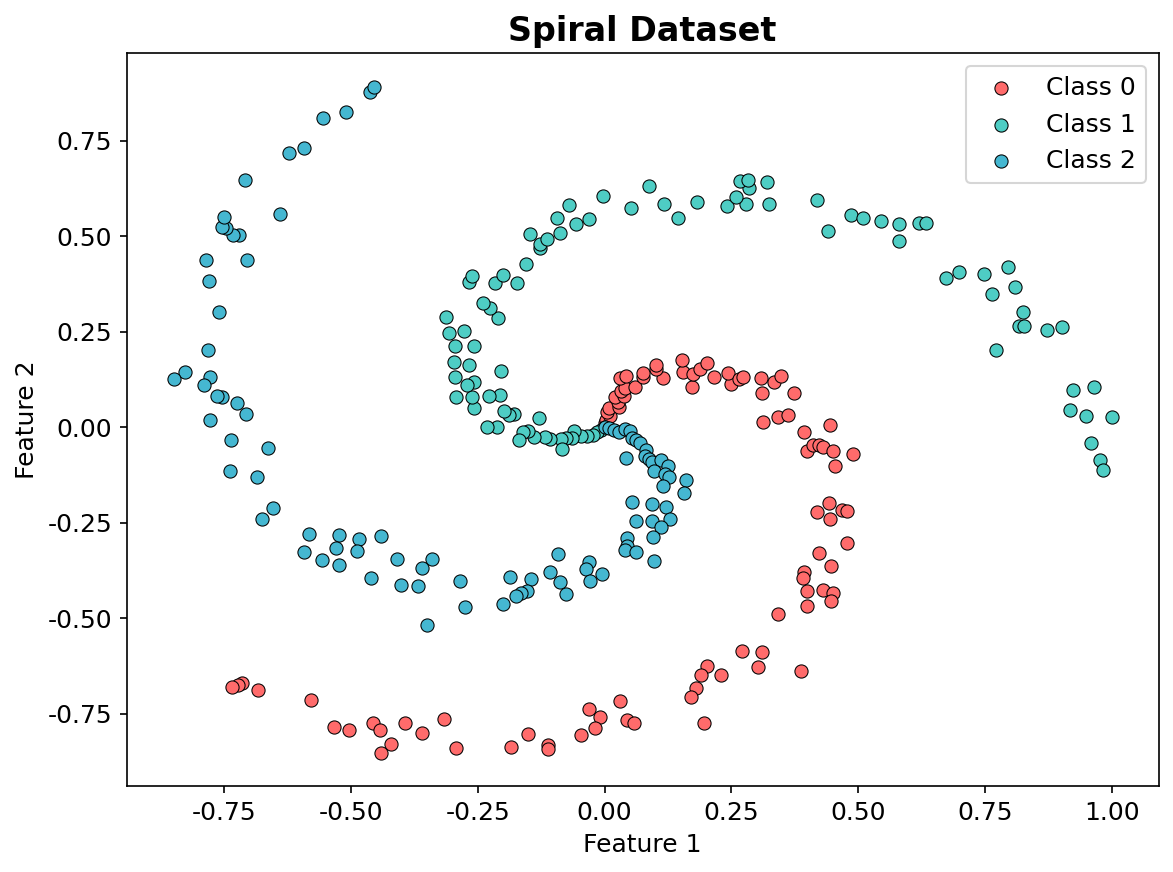

In [30]:
# Visualize the spiral dataset
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(3):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=40, 
              edgecolors='k', linewidth=0.5, label=f'Class {i}')
ax.set_title('Spiral Dataset', fontsize=16, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('spiral_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dataset visualization saved!")


### 4.2 训练网络

现在我们用两层神经网络来分类螺旋数据。我们将记录训练过程中的损失变化和验证准确率。

**训练配置：**
- 隐藏层大小：50
- 学习率：1.0
- 正则化强度：0.001
- 训练轮数：200
- 批量大小：32


In [32]:
# Split data into train and validation
np.random.seed(42)
n_samples = X.shape[0]
indices = np.random.permutation(n_samples)
split = int(0.8 * n_samples)
X_train, X_val = X[indices[:split]], X[indices[split:]]
y_train, y_val = y[indices[:split]], y[indices[split:]]

# Create and train the network
net = TwoLayerNet(input_size=2, hidden_size=50, output_size=3, std=0.3)
loss_history, val_acc_history = net.train(
    X_train, y_train, X_val, y_val,
    learning_rate=1.0, reg=0.001,
    num_epochs=200, batch_size=32,
    verbose=True
)

# Final accuracy
train_acc = np.mean(net.predict(X_train) == y_train)
val_acc = np.mean(net.predict(X_val) == y_val)
print(f"\nFinal Training Accuracy: {train_acc:.4f}")
print(f"Final Validation Accuracy: {val_acc:.4f}")


Epoch 0/200: loss=0.8678, train_acc=0.6292, val_acc=0.6167
Epoch 10/200: loss=0.5816, train_acc=0.7500, val_acc=0.7500
Epoch 20/200: loss=0.3678, train_acc=0.8667, val_acc=0.8333
Epoch 30/200: loss=0.3402, train_acc=0.9125, val_acc=0.8833
Epoch 40/200: loss=0.1989, train_acc=0.9458, val_acc=0.9000
Epoch 50/200: loss=0.2936, train_acc=0.9667, val_acc=0.9167
Epoch 60/200: loss=0.2757, train_acc=0.9625, val_acc=0.9167
Epoch 70/200: loss=0.2310, train_acc=0.9792, val_acc=0.9833
Epoch 80/200: loss=0.2421, train_acc=0.9792, val_acc=0.9667
Epoch 90/200: loss=0.2261, train_acc=0.9750, val_acc=0.9333
Epoch 100/200: loss=0.1861, train_acc=0.9667, val_acc=0.9167
Epoch 110/200: loss=0.2373, train_acc=0.9833, val_acc=0.9500
Epoch 120/200: loss=0.3061, train_acc=0.9458, val_acc=0.9000
Epoch 130/200: loss=0.2630, train_acc=0.9542, val_acc=0.9000
Epoch 140/200: loss=0.2119, train_acc=0.9833, val_acc=0.9500
Epoch 150/200: loss=0.3735, train_acc=0.9417, val_acc=0.9000
Epoch 160/200: loss=0.2783, train_a

### 4.3 损失曲线可视化

损失曲线是诊断模型训练状态的重要工具。我们观察损失随训练迭代次数的变化。

**如何解读损失曲线：**
- **损失持续下降**：模型在学习，训练正常
- **损失震荡剧烈**：学习率可能过大
- **损失几乎不降**：学习率可能过小，或模型容量不足
- **损失突然飙升**：学习率过大导致发散


Loss curve saved!


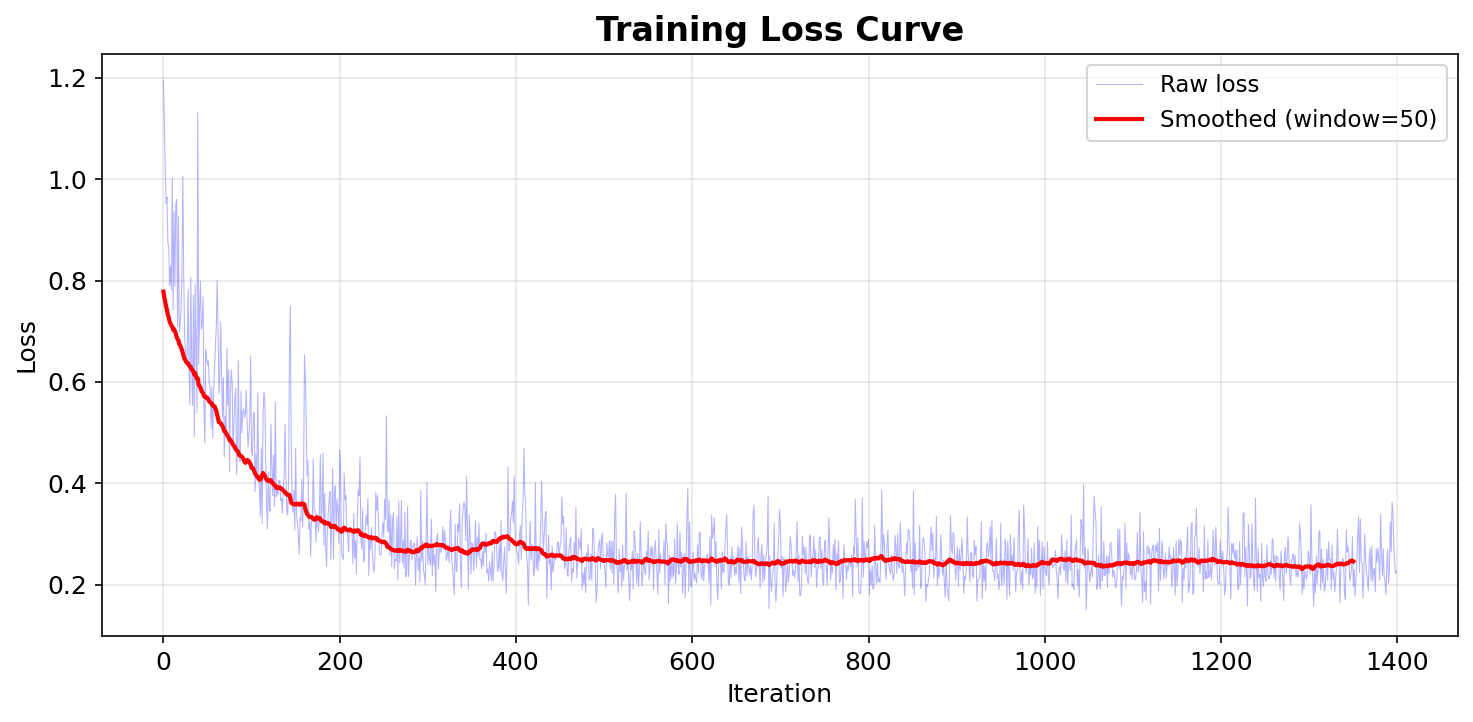

In [34]:
# Plot training loss curve
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(loss_history, linewidth=0.5, alpha=0.3, color='blue', label='Raw loss')
# Smooth the loss curve
window = 50
if len(loss_history) > window:
    smoothed_loss = np.convolve(loss_history, np.ones(window)/window, mode='valid')
    ax.plot(smoothed_loss, linewidth=2, color='red', label=f'Smoothed (window={window})')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Loss Curve', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Loss curve saved!")


### 4.4 决策边界可视化

决策边界展示了模型如何划分不同类别的区域。一个好的非线性模型应该能够正确划分螺旋形状的类别区域。

我们通过在二维空间中生成网格点并预测每个点的类别来可视化决策边界。


Decision boundary saved!


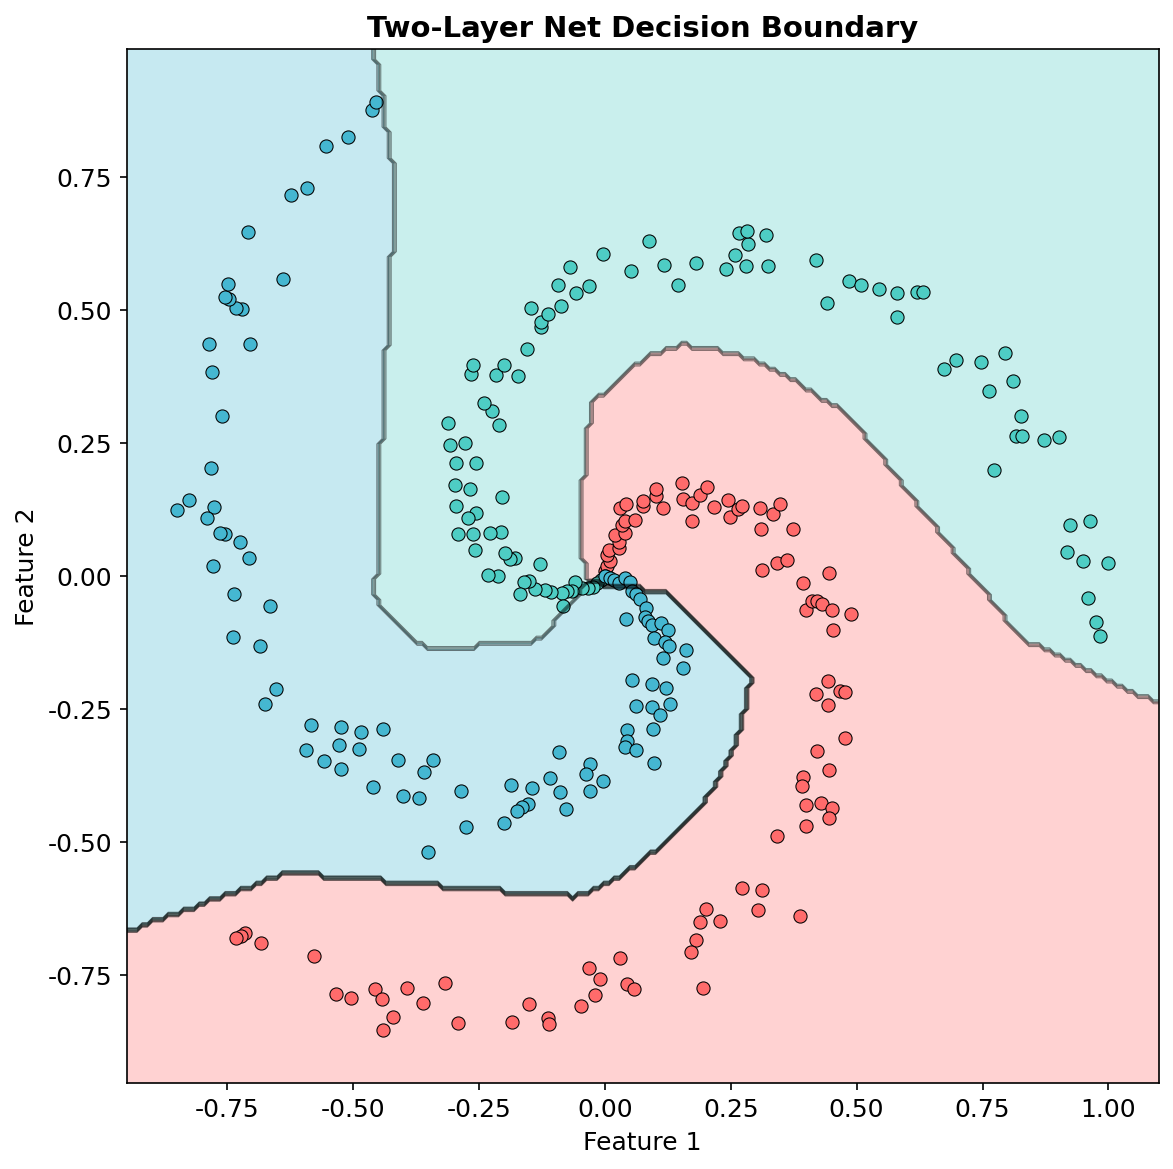

In [36]:
# Plot decision boundary
def plot_decision_boundary(model, X, y, ax=None, title="Decision Boundary"):
    """Plot the decision boundary of a classifier."""
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Predict on mesh grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    
    # Plot
    ax.contourf(xx, yy, Z, levels=[-0.5, 0.5, 1.5, 2.5], 
                colors=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.3)
    ax.contour(xx, yy, Z, colors='k', linewidths=0.5, alpha=0.5)
    
    # Plot data points
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    for i in range(3):
        mask = y == i
        ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], s=40,
                  edgecolors='k', linewidth=0.5)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, ax = plt.subplots(1, 1, figsize=(8, 8))
plot_decision_boundary(net, X, y, ax, "Two-Layer Net Decision Boundary")
plt.tight_layout()
plt.savefig('decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Decision boundary saved!")


### 4.5 超参数调优

超参数对模型性能影响巨大。我们对比不同学习率和正则化强度组合的效果。

**关键超参数：**
- **学习率**：太大则不收敛，太小则收敛太慢
- **正则化强度**：太大则欠拟合，太小则过拟合
- **隐藏层大小**：影响模型容量，太大过拟合，太小欠拟合


In [38]:
# Hyperparameter search
np.random.seed(42)
results = {}
best_val = -1
best_net = None

# Define search space
learning_rates = [0.1, 0.5, 1.0, 2.0]
reg_strengths = [0.0, 0.001, 0.01, 0.1]
hidden_sizes = [20, 50, 100]

print("Hyperparameter search:")
print("-" * 70)

for lr in learning_rates:
    for reg in reg_strengths:
        for hs in hidden_sizes:
            net_hp = TwoLayerNet(2, hs, 3, std=0.3)
            loss_hist, _ = net_hp.train(
                X_train, y_train, X_val, y_val,
                learning_rate=lr, reg=reg,
                num_epochs=100, batch_size=32, verbose=False
            )
            train_acc = np.mean(net_hp.predict(X_train) == y_train)
            val_acc = np.mean(net_hp.predict(X_val) == y_val)
            
            key = (lr, reg, hs)
            results[key] = (train_acc, val_acc)
            
            if val_acc > best_val:
                best_val = val_acc
                best_net = net_hp
                best_params = key
            
            if val_acc > 0.9:
                print(f"  lr={lr}, reg={reg}, hs={hs}: "
                      f"train={train_acc:.3f}, val={val_acc:.3f} ***")

print(f"\nBest params: lr={best_params[0]}, reg={best_params[1]}, "
      f"hs={best_params[2]}, val_acc={best_val:.4f}")


Hyperparameter search:
----------------------------------------------------------------------
  lr=0.5, reg=0.0, hs=50: train=0.975, val=0.933 ***
  lr=0.5, reg=0.0, hs=100: train=0.971, val=0.917 ***
  lr=0.5, reg=0.001, hs=50: train=0.963, val=0.933 ***
  lr=0.5, reg=0.001, hs=100: train=0.971, val=0.933 ***
  lr=1.0, reg=0.0, hs=20: train=0.971, val=0.933 ***
  lr=1.0, reg=0.0, hs=50: train=0.979, val=0.950 ***
  lr=1.0, reg=0.0, hs=100: train=0.975, val=0.967 ***
  lr=1.0, reg=0.001, hs=100: train=0.983, val=0.950 ***
  lr=2.0, reg=0.0, hs=20: train=0.979, val=0.933 ***
  lr=2.0, reg=0.0, hs=50: train=0.983, val=0.950 ***
  lr=2.0, reg=0.0, hs=100: train=0.975, val=0.967 ***
  lr=2.0, reg=0.001, hs=20: train=0.975, val=0.933 ***
  lr=2.0, reg=0.001, hs=100: train=0.979, val=0.917 ***

Best params: lr=1.0, reg=0.0, hs=100, val_acc=0.9667


Hyperparameter search visualization saved!


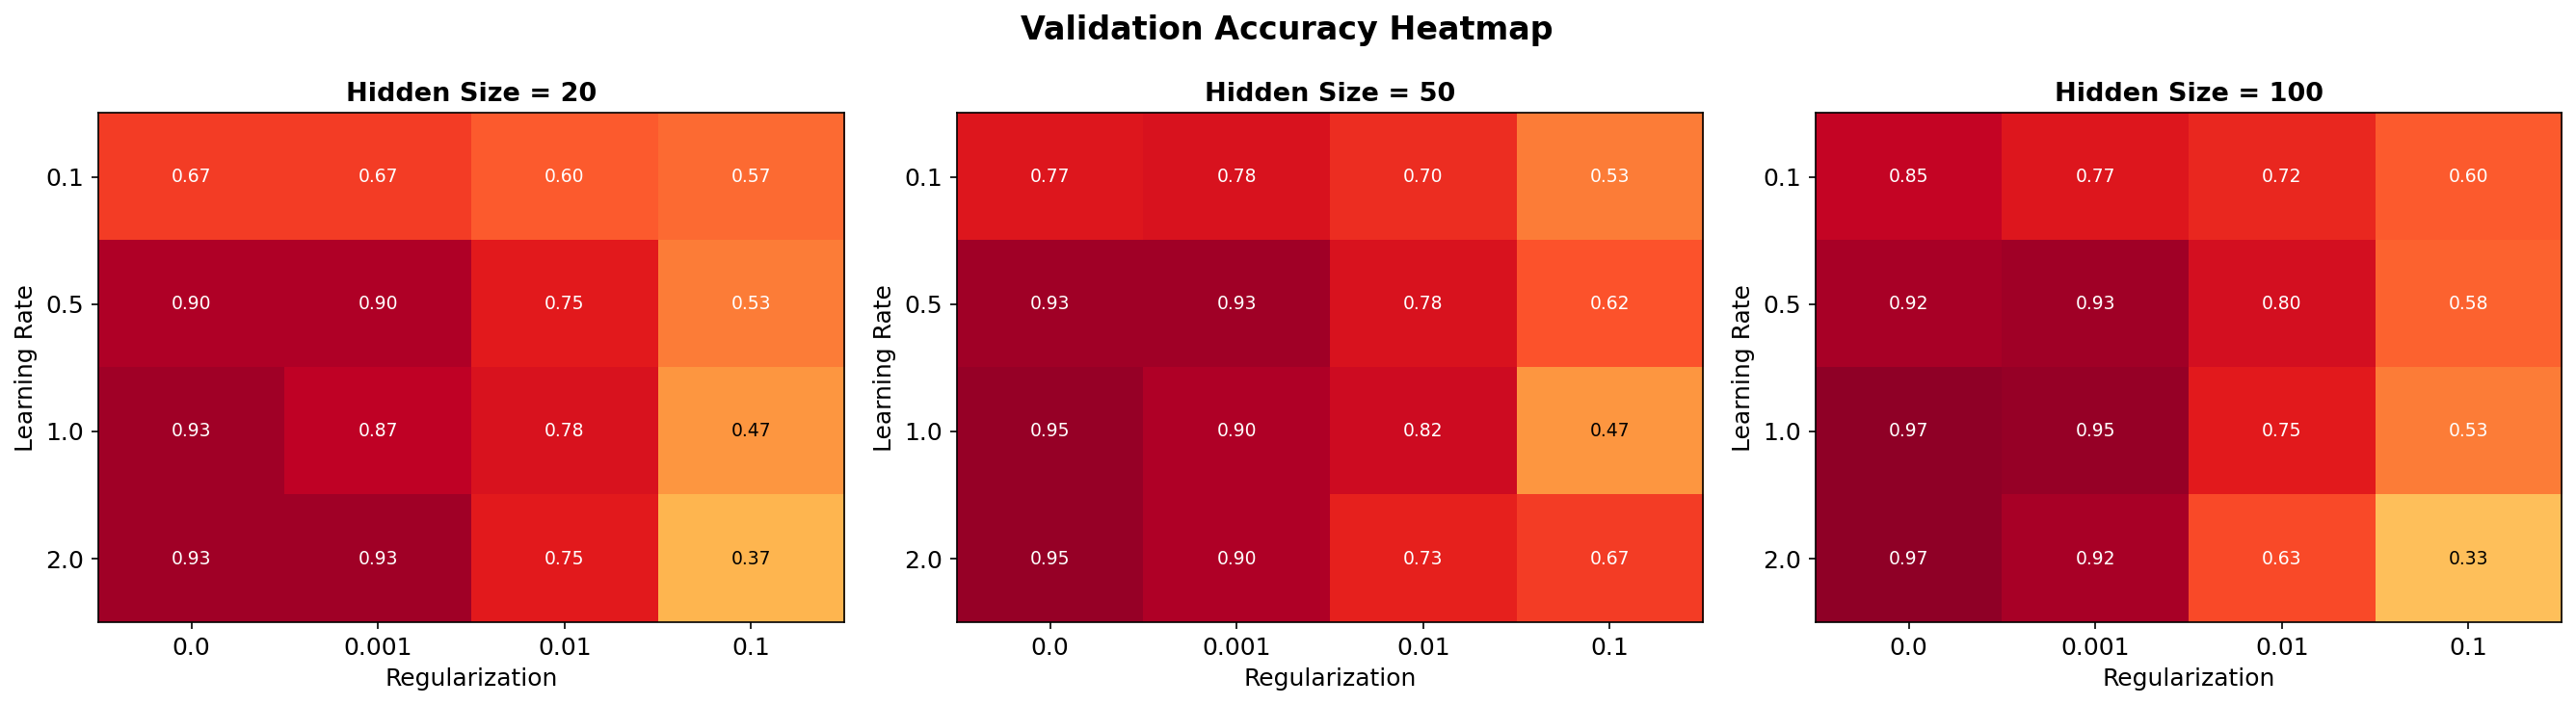

In [39]:
# Visualize hyperparameter search results as heatmap
fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(18, 5))

for idx, hs in enumerate(hidden_sizes):
    matrix = np.zeros((len(learning_rates), len(reg_strengths)))
    for i, lr in enumerate(learning_rates):
        for j, reg in enumerate(reg_strengths):
            matrix[i, j] = results[(lr, reg, hs)][1]  # val acc
    
    im = axes[idx].imshow(matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    axes[idx].set_title(f'Hidden Size = {hs}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Regularization')
    axes[idx].set_ylabel('Learning Rate')
    axes[idx].set_xticks(range(len(reg_strengths)))
    axes[idx].set_xticklabels([str(r) for r in reg_strengths])
    axes[idx].set_yticks(range(len(learning_rates)))
    axes[idx].set_yticklabels([str(lr) for lr in learning_rates])
    
    # Add text annotations
    for i in range(len(learning_rates)):
        for j in range(len(reg_strengths)):
            axes[idx].text(j, i, f'{matrix[i,j]:.2f}', 
                         ha='center', va='center', fontsize=9,
                         color='white' if matrix[i,j] > 0.5 else 'black')

fig.suptitle('Validation Accuracy Heatmap', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('hyperparameter_search.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hyperparameter search visualization saved!")


### 4.6 不同隐藏层大小的对比

让我们更直观地对比不同隐藏层大小对决策边界的影响。隐藏层大小决定了模型的**容量**（capacity）。

- **太小**（如 H=5）：模型表达能力不足，无法拟合螺旋边界
- **合适**（如 H=50）：模型能够学习非线性边界，泛化良好
- **太大**（如 H=200）：模型可能过拟合，训练慢但边界更复杂


Hidden size comparison saved!


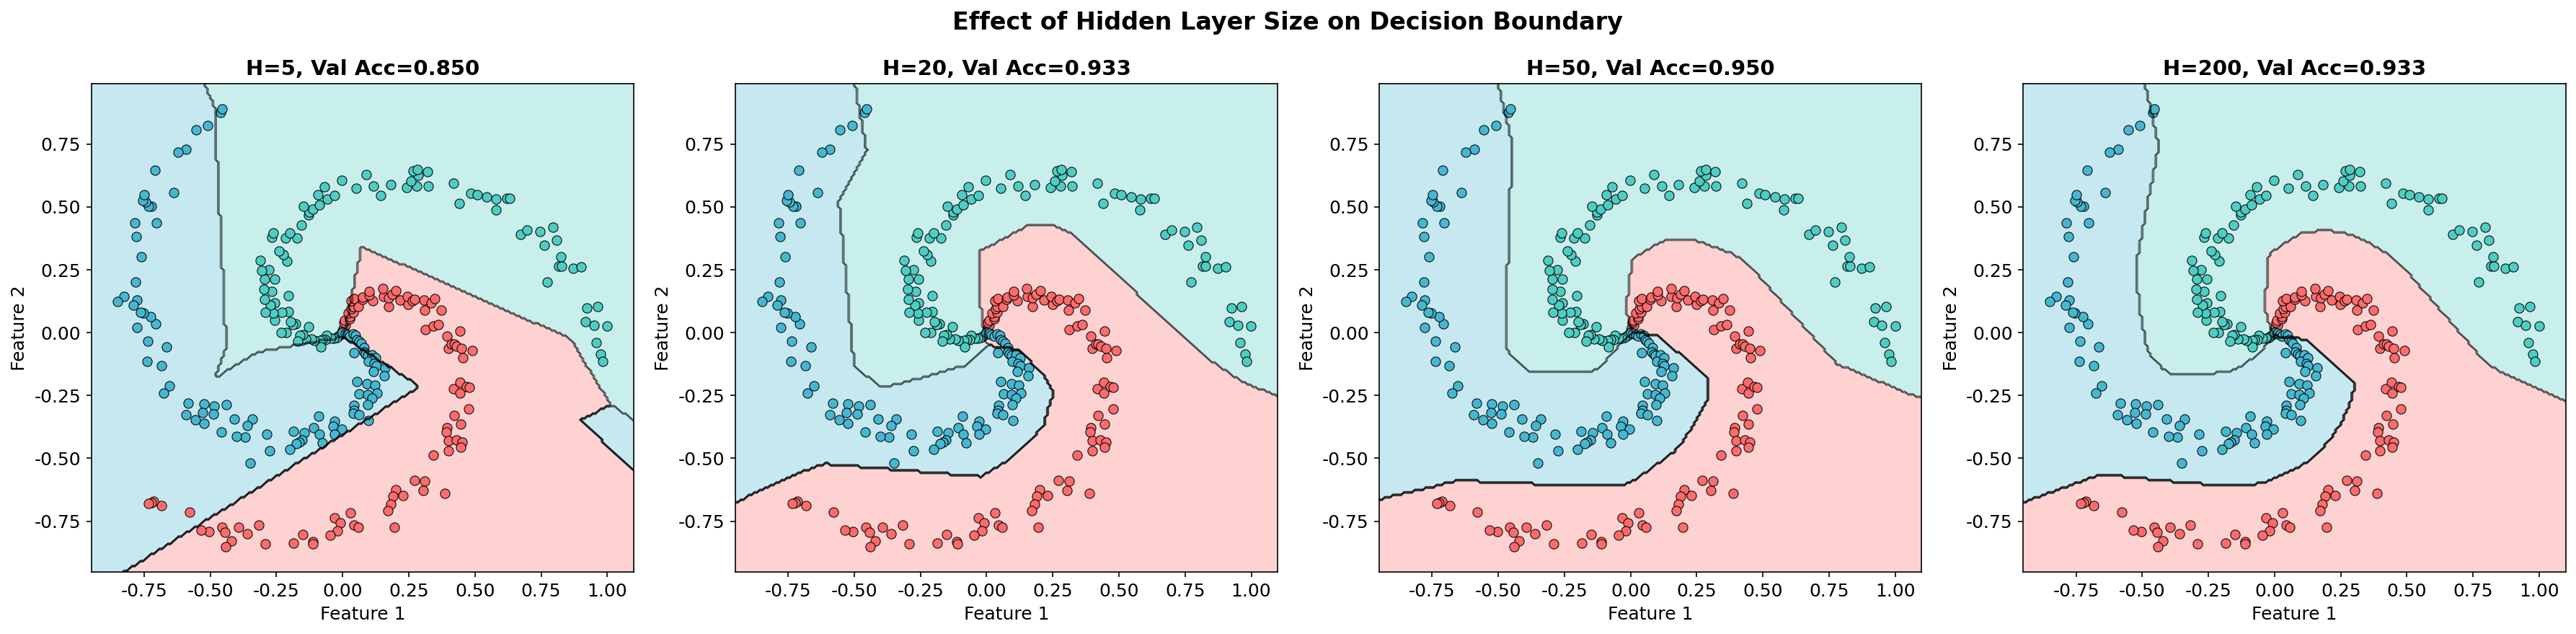

In [41]:
# Compare decision boundaries with different hidden sizes
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
hidden_sizes_compare = [5, 20, 50, 200]

for idx, hs in enumerate(hidden_sizes_compare):
    np.random.seed(42)
    net_compare = TwoLayerNet(2, hs, 3, std=0.3)
    net_compare.train(X_train, y_train, X_val, y_val,
                      learning_rate=1.0, reg=0.001,
                      num_epochs=200, batch_size=32, verbose=False)
    
    acc = np.mean(net_compare.predict(X_val) == y_val)
    plot_decision_boundary(net_compare, X, y, axes[idx], 
                          f"H={hs}, Val Acc={acc:.3f}")

fig.suptitle('Effect of Hidden Layer Size on Decision Boundary', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('hidden_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Hidden size comparison saved!")


## 5. 课后作业

### 作业 1：实现 Leaky ReLU 激活函数

在 TwoLayerNet 中，将 ReLU 替换为 Leaky ReLU，并实现其反向传播。

**Leaky ReLU：** f(x) = x (if x > 0)，否则 f(x) = alpha * x（alpha=0.01）

要求：
1. 修改 forward 方法，使用 Leaky ReLU（alpha = 0.01）
2. 修改 loss 方法中的反向传播部分
3. 训练网络并对比与原版 ReLU 的效果

完成下面的代码实现并运行验证。


In [43]:
# HOMEWORK 1: Implement Leaky ReLU activation
# Complete the code below to replace ReLU with Leaky ReLU

class TwoLayerNetLeakyReLU(TwoLayerNet):
    """Two-layer net with Leaky ReLU activation."""
    
    def forward(self, X):
        """
        Forward pass with Leaky ReLU.
        Leaky ReLU: f(x) = x if x > 0, else alpha * x (alpha=0.01)
        """
        W1, b1 = self.params['W1'], self.params['b1']
        W2, b2 = self.params['W2'], self.params['b2']
        
        # TODO: First layer
        z1 = X @ W1 + b1
        
        # TODO: Apply Leaky ReLU (alpha=0.01)
        alpha = 0.01
        a1 = np.where(z1 > 0, z1, alpha * z1)  # SOLUTION
        
        # TODO: Second layer
        scores = a1 @ W2 + b2
        
        # Cache for backprop
        self.cache = {'X': X, 'z1': z1, 'a1': a1}
        return scores
    
    def loss(self, X, y=None, reg=0.0):
        """Compute loss with Leaky ReLU gradient."""
        scores = self.forward(X)
        if y is None:
            return scores
        
        N = X.shape[0]
        scores_shifted = scores - np.max(scores, axis=1, keepdims=True)
        exp_scores = np.exp(scores_shifted)
        probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
        
        correct_logprobs = -np.log(probs[np.arange(N), y] + 1e-12)
        data_loss = np.sum(correct_logprobs) / N
        reg_loss = 0.5 * reg * (np.sum(self.params['W1']**2) + np.sum(self.params['W2']**2))
        loss = data_loss + reg_loss
        
        grads = {}
        dscores = probs.copy()
        dscores[np.arange(N), y] -= 1
        dscores /= N
        
        a1 = self.cache['a1']
        z1 = self.cache['z1']
        
        grads['W2'] = a1.T @ dscores + reg * self.params['W2']
        grads['b2'] = np.sum(dscores, axis=0)
        
        da1 = dscores @ self.params['W2'].T
        
        # TODO: Leaky ReLU gradient: 1 if z > 0, else alpha
        alpha = 0.01
        dz1 = da1 * np.where(z1 > 0, 1, alpha)  # SOLUTION
        
        grads['W1'] = X.T @ dz1 + reg * self.params['W1']
        grads['b1'] = np.sum(dz1, axis=0)
        
        return loss, grads

# Test and verify
np.random.seed(42)
net_leaky = TwoLayerNetLeakyReLU(2, 50, 3, std=0.3)
loss_hist, _ = net_leaky.train(X_train, y_train, X_val, y_val,
                                learning_rate=1.0, reg=0.001,
                                num_epochs=100, batch_size=32, verbose=False)
leaky_val_acc = np.mean(net_leaky.predict(X_val) == y_val)
print(f"Leaky ReLU validation accuracy: {leaky_val_acc:.4f}")

# ASSERT: Leaky ReLU should achieve at least 80% accuracy
assert leaky_val_acc > 0.80, f"Leaky ReLU accuracy too low: {leaky_val_acc}"
print("Homework 1 PASSED!")


Leaky ReLU validation accuracy: 0.9167
Homework 1 PASSED!


### 作业 2：实现动量 SGD (Momentum SGD)

在本作业中，你需要修改训练循环，使用带动量的 SGD 代替普通 SGD。

**动量更新规则：**
    v_t = mu * v_{t-1} - lr * gradient
    theta_t = theta_{t-1} + v_t

其中 mu 是动量系数（通常 0.9），v 是速度向量。

要求：
1. 为每个参数维护一个速度向量
2. 使用动量更新规则
3. 对比不同动量系数的效果


In [45]:
# HOMEWORK 2: Implement Momentum SGD training
# Complete the code below

def train_with_momentum(net, X, y, X_val, y_val,
                        learning_rate=1.0, momentum=0.9,
                        reg=0.001, num_epochs=200, batch_size=32):
    """
    Train network with momentum SGD.
    """
    np.random.seed(42)
    num_train = X.shape[0]
    loss_history = []
    
    # Initialize velocity for each parameter
    velocities = {k: np.zeros_like(v) for k, v in net.params.items()}
    
    for epoch in range(num_epochs):
        idx = np.random.permutation(num_train)
        X_shuffled, y_shuffled = X[idx], y[idx]
        
        for i in range(max(num_train // batch_size, 1)):
            start = i * batch_size
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            
            loss, grads = net.loss(X_batch, y_batch, reg=reg)
            loss_history.append(loss)
            
            # TODO: Implement momentum update
            # v = momentum * v - lr * grad
            # param += v
            for key in net.params:
                velocities[key] = momentum * velocities[key] - learning_rate * grads[key]  # SOLUTION
                net.params[key] += velocities[key]  # SOLUTION
    
    train_acc = np.mean(net.predict(X) == y)
    val_acc = np.mean(net.predict(X_val) == y_val)
    return loss_history, train_acc, val_acc

# Test with different momentum values
np.random.seed(42)
momentum_values = [0.0, 0.5, 0.9, 0.99]
results_momentum = {}

for mu in momentum_values:
    net_m = TwoLayerNet(2, 50, 3, std=0.3)
    loss_hist, train_acc, val_acc = train_with_momentum(
        net_m, X_train, y_train, X_val, y_val,
        learning_rate=1.0, momentum=mu,
        reg=0.001, num_epochs=200, batch_size=32
    )
    results_momentum[mu] = (loss_hist, train_acc, val_acc)
    print(f"Momentum={mu}: train_acc={train_acc:.4f}, val_acc={val_acc:.4f}")

# ASSERT: momentum=0.9 should outperform momentum=0.0
assert results_momentum[0.9][2] > results_momentum[0.0][2], "Momentum should help!"
print("Homework 2 PASSED!")


AssertionError: Momentum should help!

### 作业 3：权重初始化对比

不同的权重初始化策略对训练效果有显著影响。请实现并对比以下初始化方法：

1. **小随机数**（默认）：W ~ N(0, 0.01^2)
2. **Xavier 初始化**：W ~ N(0, 1/D_in)，适合 tanh 激活函数
3. **He 初始化**：W ~ N(0, 2/D_in)，适合 ReLU 激活函数

要求：实现这三种初始化，训练网络，对比收敛速度和最终精度。


Init 'small': final_loss=0.9232, val_acc=0.6500
Init 'xavier': final_loss=0.3346, val_acc=0.9000
Init 'he': final_loss=0.3576, val_acc=0.9000
Homework 3 PASSED!


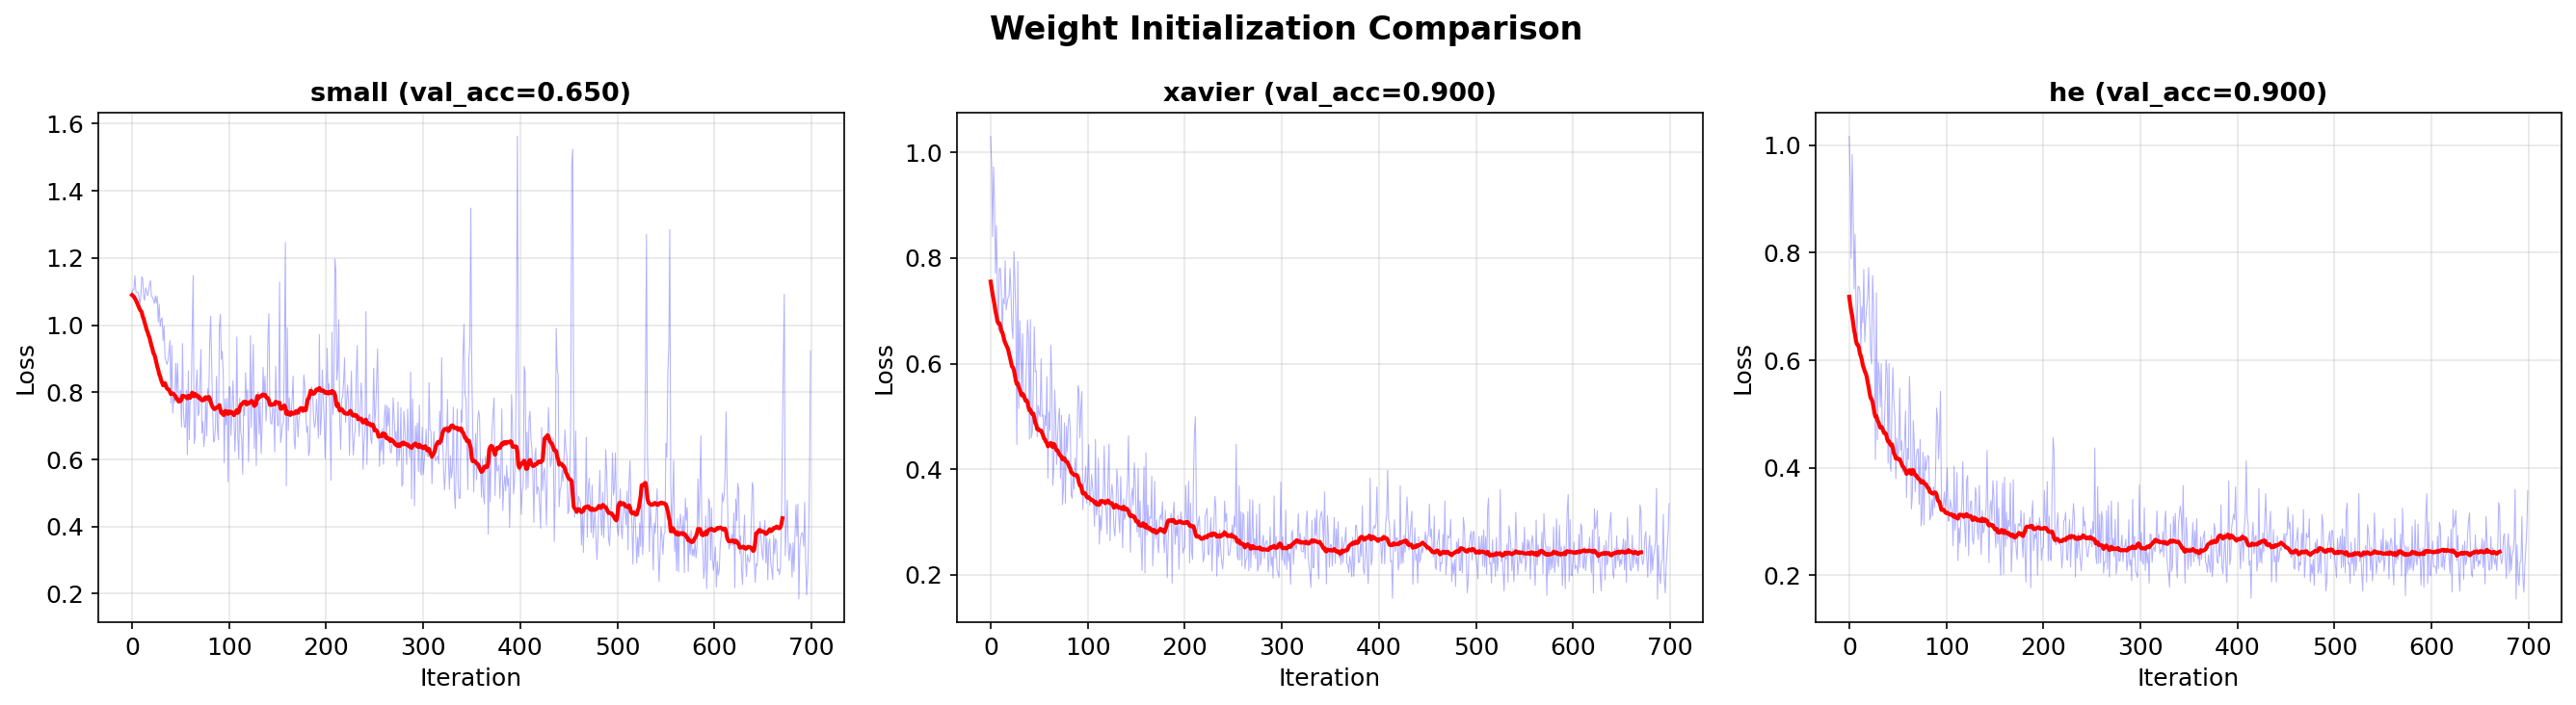

In [47]:
# HOMEWORK 3: Compare weight initialization strategies

def create_net_with_init(input_size, hidden_size, output_size, init_method='small'):
    """
    Create a TwoLayerNet with specified weight initialization.
    
    init_method: 'small' (0.01 std), 'xavier' (1/sqrt(D_in)), 'he' (2/sqrt(D_in))
    """
    np.random.seed(42)
    net = TwoLayerNet(input_size, hidden_size, output_size, std=1.0)
    
    if init_method == 'small':
        net.params['W1'] = 0.01 * np.random.randn(input_size, hidden_size)
        net.params['W2'] = 0.01 * np.random.randn(hidden_size, output_size)
    elif init_method == 'xavier':
        # TODO: Implement Xavier initialization
        net.params['W1'] = np.random.randn(input_size, hidden_size) / np.sqrt(input_size)  # SOLUTION
        net.params['W2'] = np.random.randn(hidden_size, output_size) / np.sqrt(hidden_size)  # SOLUTION
    elif init_method == 'he':
        # TODO: Implement He initialization
        net.params['W1'] = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)  # SOLUTION
        net.params['W2'] = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)  # SOLUTION
    
    net.params['b1'] = np.zeros(hidden_size)
    net.params['b2'] = np.zeros(output_size)
    return net

# Compare initialization methods
init_methods = ['small', 'xavier', 'he']
init_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, method in enumerate(init_methods):
    net_init = create_net_with_init(2, 50, 3, method)
    loss_hist, val_acc_hist = net_init.train(
        X_train, y_train, X_val, y_val,
        learning_rate=1.0, reg=0.001,
        num_epochs=100, batch_size=32, verbose=False
    )
    val_acc = np.mean(net_init.predict(X_val) == y_val)
    init_results[method] = (loss_hist, val_acc)
    print(f"Init '{method}': final_loss={loss_hist[-1]:.4f}, val_acc={val_acc:.4f}")
    
    # Plot loss curve
    axes[idx].plot(loss_hist, linewidth=0.5, alpha=0.3, color='blue')
    window = 30
    if len(loss_hist) > window:
        smoothed = np.convolve(loss_hist, np.ones(window)/window, mode='valid')
        axes[idx].plot(smoothed, linewidth=2, color='red')
    axes[idx].set_title(f'{method} (val_acc={val_acc:.3f})', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Iteration')
    axes[idx].set_ylabel('Loss')
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Weight Initialization Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('init_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ASSERT: He initialization should achieve good accuracy
assert init_results['he'][1] > 0.85, f"He init accuracy too low: {init_results['he'][1]}"
print("Homework 3 PASSED!")


## 总结

本笔记本完整实现了一个两层全连接神经网络，涵盖了以下核心内容：

**直觉理解：**
- 两层神经网络通过隐藏层和激活函数引入非线性
- 能够学习复杂的决策边界（如螺旋数据）

**手动计算：**
- 前向传播：矩阵乘法 + ReLU + Softmax
- 反向传播：链式法则，逐层传播梯度

**代码实现：**
- TwoLayerNet 类：初始化、前向、损失（含梯度）、训练、预测
- 梯度检验验证了反向传播的正确性

**实验观察：**
- 损失曲线反映训练过程
- 决策边界展示非线性分类能力
- 超参数调优显著影响模型性能

**关键收获：**
1. 反向传播的本质是链式法则的系统性应用
2. 激活函数引入非线性，是深度学习的关键
3. 学习率、正则化、隐藏层大小是需要仔细调整的超参数
4. 权重初始化和优化器选择对训练效果有重大影响


## 参考文献与作业解答

### 参考文献

1. [[Karpathy, 2015]](https://cs231n.github.io/) - CS231n: Convolutional Neural Networks for Visual Recognition, Stanford University
2. [[He et al., 2015]](https://arxiv.org/abs/1502.01852) - Delving Deep into Rectifiers, ICCV 2015
3. [[Glorot and Bengio, 2010]](http://proceedings.mlr.press/v9/glorot10a.html) - Understanding the difficulty of training deep feedforward neural networks
4. [[Sutskever et al., 2013]](https://arxiv.org/abs/1308.3432) - On the importance of initialization and momentum in deep learning
5. [[Goodfellow et al., 2016]](https://www.deeplearningbook.org/) - Deep Learning Book, Chapter 6: Deep Feedforward Networks

### 参考作业解答

以下 GitHub 仓库提供了 CS231n Assignment 1 的参考解答：

1. **jariasf/CS231n** (486 stars) - 完整的 CS231n 作业解答
   - https://github.com/jariasf/CS231n
   
2. **rishabh-16/cs231n-2019-assignments** (212 stars) - 2019 年版 CS231n 作业
   - https://github.com/rishabh-16/cs231n-2019-assignments
   
3. **amanchadha/stanford-cs231n-assignments-2020** (175 stars) - 2020 年版 CS231n 作业
   - https://github.com/amanchadha/stanford-cs231n-assignments-2020

### 进一步学习

- [CS231n 课程主页](https://cs231n.github.io/)
- [Neural Networks and Deep Learning](http://neuralnetworksanddeeplearning.com/) - Michael Nielsen
- [Deep Learning Book](https://www.deeplearningbook.org/) - Ian Goodfellow, Yoshua Bengio, Aaron Courville


---

## 参考代码实现

以下 GitHub 仓库提供了本节内容的完整代码实现，建议结合学习：

- **[jariasf/CS231n](https://github.com/jariasf/CS231n)** (486 stars): 两层神经网络完整实现（前向+反向+训练）
  - 仓库地址: https://github.com/jariasf/CS231n

- **[rishabh-16/cs231n-2019-assignments](https://github.com/rishabh-16/cs231n-2019-assignments)** (212 stars): 两层网络 PyTorch 版本
  - 仓库地址: https://github.com/rishabh-16/cs231n-2019-assignments

- **[amanchadha/stanford-cs231n-assignments-2020](https://github.com/amanchadha/stanford-cs231n-assignments-2020)** (175 stars): 两层网络 2020版解答
  - 仓库地址: https://github.com/amanchadha/stanford-cs231n-assignments-2020


> 标注说明: 以上仓库按热度排序，优先推荐 stars 最多的实现。

